In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas
data = pandas.read_csv("churn.csv")

data = data.drop(columns = [ 'customerID' ])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [3]:
import sklearn.model_selection

X = data.drop(columns = [ "Churn" ])
y = (data["Churn"] == "Yes").to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 1
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 19), (704, 19), (6328,), (704,))

In [4]:
numeric = [ "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))

len(numeric), len(categorical), len(X_train.columns)

(4, 15, 19)

In [5]:
import sklearn.compose
import sklearn.preprocessing

ct = sklearn.compose.ColumnTransformer(
    transformers=[
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(drop = 'first'), categorical)
    ]
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train.shape, X_test.shape

((6328, 30), (704, 30))

In [6]:
y_train.shape, y_test.shape

((6328,), (704,))

In [7]:
import sklearn.preprocessing

ss = sklearn.preprocessing.StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [152]:
import tqdm
from utils import estimate_quality

import xgboost
import catboost
import sklearn.svm
import sklearn.tree
import sklearn.ensemble
import sklearn.neighbors
import sklearn.naive_bayes
import sklearn.linear_model
import sklearn.neural_network

models = [
    # neighbors
    sklearn.neighbors.KNeighborsClassifier(n_jobs = -1, n_neighbors = 50),
    sklearn.neighbors.RadiusNeighborsClassifier(n_jobs = -1, radius = 7),

    # naive_bayes
    sklearn.naive_bayes.BernoulliNB(),
    sklearn.naive_bayes.GaussianNB(),

    # linear_model
    sklearn.linear_model.LogisticRegression(),
    
    # svm
    sklearn.svm.SVC(probability = True),
    sklearn.svm.NuSVC(probability = True),
    
    # tree
    sklearn.tree.DecisionTreeClassifier(),
    sklearn.tree.ExtraTreeClassifier(),

    # ensemble
    sklearn.ensemble.BaggingClassifier(n_estimators = 100, random_state = 42, n_jobs = -1),
    sklearn.ensemble.AdaBoostClassifier(n_estimators = 500, algorithm = 'SAMME', random_state = 42),
    sklearn.ensemble.ExtraTreesClassifier(n_estimators = 500, random_state = 42, n_jobs = -1),
    sklearn.ensemble.RandomForestClassifier(n_estimators = 1000, random_state = 42, n_jobs = -1),
    sklearn.ensemble.GradientBoostingClassifier(n_estimators = 1000, random_state = 42),
    sklearn.ensemble.HistGradientBoostingClassifier(random_state = 42),

    # neural_network
    sklearn.neural_network.MLPClassifier(max_iter = 2000),
    
    # xgboost
    xgboost.XGBClassifier(n_jobs = -1, n_estimators = 50, max_depth = 4, device = 'gpu'),

    # catboost
    catboost.CatBoostClassifier(
        iterations = 600,
        depth = 4,
        random_seed = 42,
        loss_function = 'MultiClass',
        devices = '0-3',
        task_type = 'CPU',
        verbose = False
    ),
]

results = []
for model in tqdm.tqdm(models):
    model.fit(X_train_scaled, y_train)
    metrics = estimate_quality(model.predict_proba(X_test_scaled), y_test)
    results.append({ 'model': str(model), **metrics })
pandas.DataFrame(results)

 94%|█████████▍| 17/18 [00:36<00:02,  2.83s/it]

[19:32:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-10.9-x86_64-cpython-37/xgboost/src/learner.cc:627: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




100%|██████████| 18/18 [00:38<00:00,  2.15s/it]


,model,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,"KNeighborsClassifier(n_jobs=-1, n_neighbors=50)",0.802557,0.641176,0.582888,0.800851,0.610644,109,456,61,78,0.882012,0.853933,0.117988,0.358824
1,"RadiusNeighborsClassifier(n_jobs=-1, radius=7)",0.734375,0.000000,0.000000,0.802361,0.000000,0,517,0,187,1.000000,0.734375,0.000000,0.000000
2,BernoulliNB(),0.707386,0.468013,0.743316,0.802387,0.574380,139,359,158,48,0.694391,0.882064,0.305609,0.531987
3,GaussianNB(),0.640625,0.412234,0.828877,0.809659,0.550622,155,296,221,32,0.572534,0.902439,0.427466,0.587766
4,LogisticRegression(),0.798295,0.645161,0.534759,0.822857,0.584795,100,462,55,87,0.893617,0.841530,0.106383,0.354839
5,SVC(probability=True),0.801136,0.671533,0.491979,0.769464,0.567901,92,472,45,95,0.912959,0.832451,0.087041,0.328467
6,NuSVC(probability=True),0.802557,0.690476,0.465241,0.784648,0.555911,87,478,39,100,0.924565,0.826990,0.075435,0.309524
7,DecisionTreeClassifier(),0.732955,0.497512,0.534759,0.668801,0.515464,100,416,101,87,0.804642,0.827038,0.195358,0.502488
8,ExtraTreeClassifier(),0.741477,0.512953,0.529412,0.672887,0.521053,99,423,94,88,0.818182,0.827789,0.181818,0.487047
9,"BaggingClassifier(n_estimators=100, n_jobs=-1,...",0.781250,0.605096,0.508021,0.793926,0.552326,95,455,62,92,0.880077,0.831810,0.119923,0.394904


In [8]:
pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

,numeric__SeniorCitizen,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__PaperlessBilling_Yes,categorical__Contract_One year,...,categorical__PaymentMethod_Mailed check,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__gender_Male,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Dependents_Yes,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__PhoneService_Yes
0,1.0,1.0,20.05,20.05,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.0,62.0,90.70,5586.45,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,64.0,47.85,3147.50,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,20.35,20.35,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
4,0.0,65.0,79.40,5071.90,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0.0,46.0,20.25,890.35,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
700,0.0,1.0,69.35,69.35,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
701,0.0,50.0,94.40,4914.90,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
702,1.0,51.0,94.00,4905.75,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [9]:
import numpy

X_train_df = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())
X_test_df = pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

for column in X_train_df.columns:
    if len(numpy.unique(X_train_df[column])) == 2:
        X_train_df[column] = X_train_df[column].astype(bool)
        X_test_df[column] = X_test_df[column].astype(bool)

X_train_df

,numeric__SeniorCitizen,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__PaperlessBilling_Yes,categorical__Contract_One year,...,categorical__PaymentMethod_Mailed check,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__gender_Male,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Dependents_Yes,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__PhoneService_Yes
0,False,35.0,85.30,2917.50,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1,False,3.0,35.15,99.75,False,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
2,False,6.0,89.50,573.30,True,False,False,True,True,False,...,False,False,False,False,False,True,False,False,False,True
3,False,72.0,94.25,6849.75,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,True
4,True,72.0,114.65,8333.95,True,False,False,True,True,False,...,False,False,True,False,False,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,False,1.0,20.20,20.20,False,True,True,False,False,False,...,True,True,False,True,True,False,False,True,False,True
6324,False,69.0,114.35,7665.80,True,False,False,True,True,False,...,False,False,True,True,False,True,True,False,True,True
6325,True,59.0,50.25,2997.45,False,False,False,True,True,False,...,False,False,False,True,False,True,False,False,False,False
6326,False,4.0,19.60,93.45,False,True,True,False,False,False,...,True,True,False,False,True,False,False,True,False,True


In [10]:
X_test_df

,numeric__SeniorCitizen,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__PaperlessBilling_Yes,categorical__Contract_One year,...,categorical__PaymentMethod_Mailed check,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__gender_Male,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Dependents_Yes,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__PhoneService_Yes
0,True,1.0,20.05,20.05,False,True,True,False,False,False,...,True,True,False,True,True,False,False,True,False,True
1,False,62.0,90.70,5586.45,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
2,False,64.0,47.85,3147.50,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
3,False,1.0,20.35,20.35,False,True,True,False,False,False,...,True,True,False,True,True,False,False,True,False,True
4,False,65.0,79.40,5071.90,False,False,False,True,True,False,...,False,False,False,False,False,True,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,False,46.0,20.25,890.35,False,True,True,False,False,False,...,False,True,False,False,True,False,True,True,False,True
700,False,1.0,69.35,69.35,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
701,False,50.0,94.40,4914.90,True,False,False,False,True,False,...,False,False,True,True,False,True,False,False,False,True
702,True,51.0,94.00,4905.75,True,False,False,True,True,True,...,False,False,False,True,False,True,False,False,False,True


In [15]:
import tqdm
import typing
import joblib

class LazyClassifierFCA:
    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series) -> None:
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.binary_X_train_positive = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.numerical_X_train_positive = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.binary_X_train_negative = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.numerical_X_train_negative = X_train[y_train == 0][self.numeric_columns].to_numpy()

        self.cache = {}

    def cached_matches(self, binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums):
        key = tuple([*binary_intersection, *numeric_intersection_minimums, *numeric_intersection_maximums])
        self.cache[key] = 1
        return

        for a, b, c in self.cache:
            if (a == binary_intersection).all() and (b == numeric_intersection_minimums).all() and (c == numeric_intersection_maximums).all():
                print('!!!!!!!!!!!!')
        self.cache.append((binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums))

        
    def classify_sample(self, sample: pandas.Series) -> typing.Any:
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        def find_matches(bin, num):
            binary_intersection = sample_bin & bin

            numeric_intersection_minimums = numpy.vstack([ sample_num, num ]).min(axis = 0)
            numeric_intersection_maximums = numpy.vstack([ sample_num, num ]).max(axis = 0)

            # key = tuple([*binary_intersection, *numeric_intersection_minimums, *numeric_intersection_maximums])
            # if key in self.cache:
            #     return self.cache[key]

            binary_positive_match = (self.binary_X_train_positive | ~binary_intersection).all(axis = 1)
            binary_negative_match = (self.binary_X_train_negative | ~binary_intersection).all(axis = 1)
            
            numerical_positive_minimum = (numeric_intersection_minimums <= self.numerical_X_train_positive)
            numerical_positive_maximum = (self.numerical_X_train_positive <= numeric_intersection_maximums)
            numerical_positive_match = (numerical_positive_minimum & numerical_positive_maximum).all(axis = 1)

            numerical_negative_minimum = (numeric_intersection_minimums <= self.numerical_X_train_negative)
            numerical_negative_maximum = (self.numerical_X_train_negative <= numeric_intersection_maximums)
            numerical_negative_match = (numerical_negative_minimum & numerical_negative_maximum).all(axis = 1)

            num_positive = (binary_positive_match & numerical_positive_match).sum()
            num_negative = (binary_negative_match & numerical_negative_match).sum()
            # self.cache[key] = (num_positive, num_negative)
            return num_positive, num_negative

        positive_classifiers = 0
        negative_classifiers = 0

        for pos_bin, pos_num in zip(self.binary_X_train_positive, self.numerical_X_train_positive):
            num_positive, num_negative = find_matches(pos_bin, pos_num)
            if 2.7 * num_positive > num_negative:
                positive_classifiers += 1

        for neg_bin, neg_num in zip(self.binary_X_train_negative, self.numerical_X_train_negative):
            num_positive, num_negative = find_matches(neg_bin, neg_num)
            if num_negative > 2.7 * num_positive:
                negative_classifiers += 1

        print('Positive: ', positive_classifiers)
        print('Negative: ', negative_classifiers)
        total = negative_classifiers + positive_classifiers
        return [ (negative_classifiers / total), (positive_classifiers / total) ]


    def predict(self, X_test: pandas.DataFrame) -> typing.List[typing.Any]:
        def do(sample):
            return self.classify_sample(sample)
        return joblib.Parallel(n_jobs = -1)(
            joblib.delayed(do)(sample)
            for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
        )

In [16]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
fca.classify_sample(X_test_df.iloc[0])

KeyboardInterrupt: 

In [16]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)

cache = set()
hits = 0
misses = 0
def get_key(sample_bin, sample_num, bin, num):
    global hits
    global misses
    binary_intersection = sample_bin & bin

    numeric_intersection_minimums = numpy.vstack([ sample_num, num ]).min(axis = 0)
    numeric_intersection_maximums = numpy.vstack([ sample_num, num ]).max(axis = 0)

    key = tuple([*binary_intersection, *numeric_intersection_minimums, *numeric_intersection_maximums])
    if key in cache:
        hits += 1
    else:
        misses += 1
        cache.add(key)

for _, sample in tqdm.tqdm(X_test_df.iterrows(), total = len(X_test_df)):
    sample_bin = sample[fca.bool_columns].to_numpy().astype(bool)
    sample_num = sample[fca.numeric_columns].to_numpy()

    for pos_bin, pos_num in zip(fca.binary_X_train_positive, fca.numerical_X_train_positive):
        get_key(sample_bin, sample_num, pos_bin, pos_num)

    for neg_bin, neg_num in zip(fca.binary_X_train_negative, fca.numerical_X_train_negative):
        get_key(sample_bin, sample_num, pos_bin, pos_num)

hits, misses, len(cache)

100%|██████████| 704/704 [00:39<00:00, 17.88it/s]


(3295079, 1159833, 1159833)

In [17]:
hits / (hits + misses)

0.7396507495546489

In [46]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
fca.predict(X_test_df[:3])





























100%|██████████| 3/3 [00:13<00:00,  4.53s/it]


[[0.5932158821982645, 0.40678411780173546],
 [0.7954635893354556, 0.20453641066454437],
 [0.8395816890292028, 0.16041831097079715]]

In [44]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
fca.predict(X_test_df[:3])





























100%|██████████| 3/3 [00:14<00:00,  4.71s/it]


[[0.5932158821982645, 0.40678411780173546],
 [0.7954635893354556, 0.20453641066454437],
 [0.8395816890292028, 0.16041831097079715]]

In [13]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
y_pred = fca.predict(X_test_df)

100%|██████████| 704/704 [06:05<00:00,  1.93it/s]


In [12]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
y_pred = fca.predict(X_test_df)

100%|██████████| 704/704 [06:02<00:00,  1.94it/s]


In [14]:
numpy.array(y_pred).shape

(704, 2)

{'Accuracy': 0.8053977272727273,
 'Precision': 0.7840909090909091,
 'Recall': 0.3689839572192513,
 'AUC-ROC': 0.821874450501143,
 'F1-score': 0.5018181818181818,
 'True Positive': 69,
 'True Negative': 498,
 'False Positive': 19,
 'False Negative': 118,
 'True Negative Rate (Specificity)': 0.9632495164410058,
 'Negative Predictive Value': 0.8084415584415584,
 'False Positive Rate': 0.0367504835589942,
 'False Discovery Rate': 0.2159090909090909}

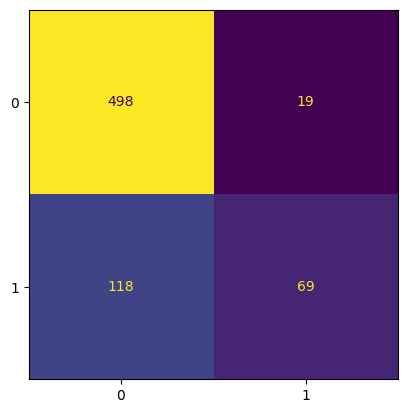

In [16]:
import matplotlib.pyplot as plt
from utils import estimate_quality

fig, axes = plt.subplots(1, 1)
estimate_quality(numpy.array(y_pred), y_test, ax = axes)

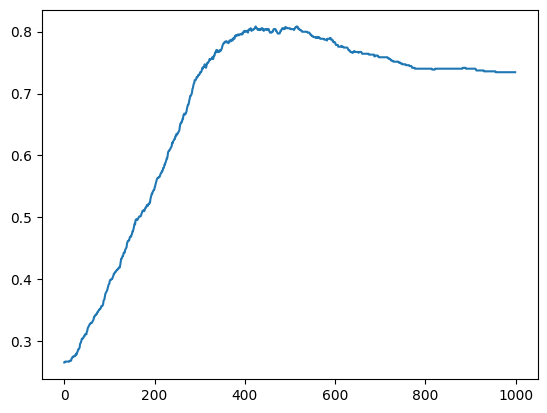

In [17]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    u = o[:, 1] > thr
    acc.append(sklearn.metrics.accuracy_score(u, y_test))

plt.plot(list(range(0, 1000)), acc)

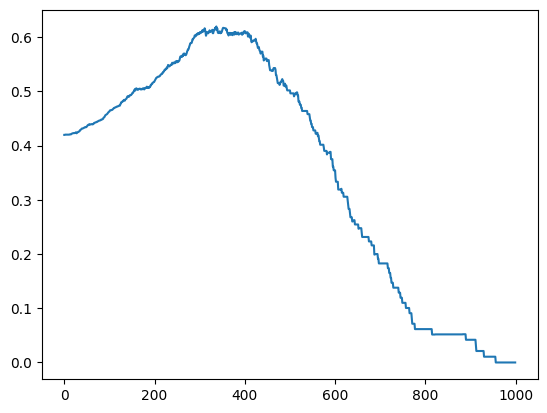

In [18]:
import sklearn.metrics

o = numpy.array(y_pred)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    u = o[:, 1] > thr
    acc.append(sklearn.metrics.f1_score(u, y_test))

plt.plot(list(range(0, 1000)), acc)

In [21]:
print('F1: ', numpy.max(acc))

F1:  0.6197183098591549
